# Supervised Learning Demo II: Classification

<br>

In this notebook we tackle a **classification** problem — predicting whether a passenger **survived** the Titanic disaster (yes or no).

Along the way we'll also handle **missing data** and encode categorical variables before training.

**What you'll learn:**
- Basic data cleaning: dropping missing values and encoding categoricals
- How Logistic Regression works for binary classification
- How to evaluate a classifier with accuracy and a confusion matrix

<br>

>
> ℹ️ Info about this notebook:
>
> - Goals: 
>   - Intro to Classification (LogisticRegression, accuracy, confusion matrix...)
>   - In addition to that, we'll also learn a few other concepts (e.g. some data cleaning, correlation and feature selection, etc.).
> - Dataset: Titanic Dataset
> - Model: Logistic Regression
> 


<br>

---

## 1. The Problem

The **Titanic** sank on April 15, 1912. Of the ~2,200 people on board, only ~710 survived.

We have data on **891 passengers**. Our goal: **predict whether a passenger survived** based on features like ticket class, sex, and fare.

This is a **binary classification** problem — the target variable `survived` is either `0` (did not survive) or `1` (survived).

| Column | Description |
|--------|-------------|
| `survived` | Target — 0 = No, 1 = Yes |
| `pclass` | Ticket class: 1 = First, 2 = Second, 3 = Third |
| `sex` | Passenger sex |
| `age` | Age in years |
| `sibsp` | # of siblings / spouses aboard |
| `parch` | # of parents / children aboard |
| `fare` | Passenger fare |
| `embarked` | Port of embarkation (C, Q, S) |

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---

## 2. Exploratory Data Analysis (EDA)

Before building a model, let's understand the data — its shape, data types, and how the target variable is distributed.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [3]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Target Distribution

Let's check how balanced our classes are. An imbalanced dataset can make accuracy a misleading metric — we'll come back to this in the evaluation section.

survived
0    549
1    342
Name: count, dtype: int64

survived
0    0.62
1    0.38
Name: proportion, dtype: float64


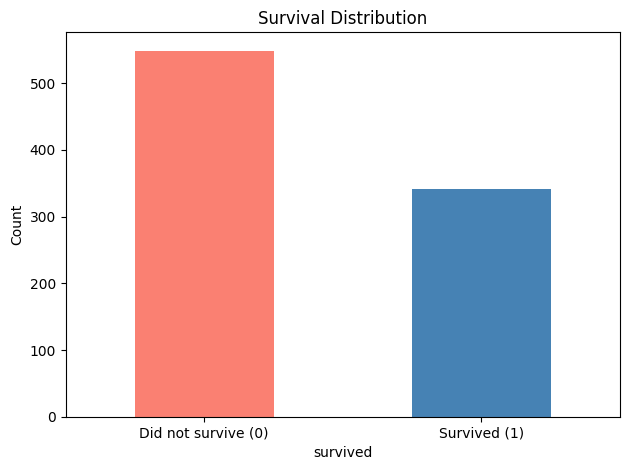

In [4]:
print(df['survived'].value_counts())
print()
print(df['survived'].value_counts(normalize=True).round(2))

df['survived'].value_counts().plot(kind='bar', color=['salmon', 'steelblue'])
plt.xticks([0, 1], ['Did not survive (0)', 'Survived (1)'], rotation=0)
plt.ylabel('Count')
plt.title('Survival Distribution')
plt.tight_layout()
plt.show()

**Observation:** About **62% did not survive** and **38% survived** — the classes are imbalanced. We'll keep this in mind when evaluating the model.

---

## 3. Data Cleaning

Data cleaning is a crucial step in any machine learning workflow, as real-world datasets are often incomplete, inconsistent, or noisy. Proper cleaning helps ensure models learn meaningful patterns rather than artifacts of poor data quality. 

This is commonly summarized by the principle **"Garbage in, garbage out"**: if the input data is flawed, the model’s outputs will be unreliable regardless of how advanced the algorithm is.


![garbage-in-garbage-out](../_images/garbage-in-garbage-out.png)

(Image source: [medium](https://ai.plainenglish.io/the-abcs-of-machine-learning-4298b308d17c))

<br>

It is also worth to mention that many algorithms cannot handle missing values — we need to clean the data before training.

Let's check which columns have missing values.

In [5]:
df.isnull().sum().sort_values(ascending=False)

deck           688
age            177
embarked         2
embark_town      2
survived         0
pclass           0
sex              0
sibsp            0
parch            0
fare             0
class            0
who              0
adult_male       0
alive            0
alone            0
dtype: int64

Four columns have missing values:

| Column | Missing | Strategy |
|--------|---------|----------|
| `deck` | 688 (77%) | Drop column |
| `age` | 177 (20%) | Drop column |
| `embark_town` | 2 | Drop column |
| `embarked` | 2 | Drop column |

**Strategy:** We'll drop any column that has missing values. In practice, you'd often *impute* them (fill with the median, mean, or a model) — but dropping is the simplest starting point.

In [6]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [7]:
# drop the column "deck"
df = df.drop(columns=["deck"])

# drop all rows with missing data
df = df.dropna(subset=["age", "embarked", "embark_town"])

In [8]:
df.isna().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

In [9]:
# Drop all columns that contain any missing values
# df = df.dropna(axis=1)

print("Remaining columns:", df.columns.tolist())
print("\nAny missing values left?", df.isnull().sum().sum())

Remaining columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']

Any missing values left? 0


In [10]:
df.isna().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

### Drop Redundant and Leakage Columns

Some remaining columns need to be removed for different reasons:

| Column | Reason |
|--------|--------|
| `alive` | ⚠️ **Data leakage** — same as `survived` but encoded as `'yes'`/`'no'` |
| `class` | Redundant — same info as `pclass` but as a string |
| `who` | Redundant — derived from `sex` |
| `adult_male` | Redundant — derived from `sex` |

> **Data leakage** means including information that directly encodes the target or that wouldn't be available at prediction time. It inflates model performance and makes it useless in the real world.

In [11]:
df = df.drop(columns=['alive', 'class', 'who', 'adult_male'])

print("Columns after dropping:", df.columns.tolist())

Columns after dropping: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'embark_town', 'alone']


### Encode Categorical Variables

Most ML algorithms require numerical input, so categories are usually converted into numbers.

The `sex` column contains strings (`'male'` / `'female'`). We convert it with `pd.get_dummies()`.

With `drop_first=True`, it removes one redundant column — so `sex` becomes a single column `sex_male`:
- `1` = male
- `0` = female

For the column `embarked`, we will follow a similar approach.


In [12]:
df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)
df = df.drop(columns=['embark_town'])

df.head()

,survived,pclass,age,sibsp,parch,fare,alone,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,False,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False,False
2,1,3,26.0,0,0,7.9250,True,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,False,True
4,0,3,35.0,0,0,8.0500,True,True,False,True


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    712 non-null    int64  
 1   pclass      712 non-null    int64  
 2   age         712 non-null    float64
 3   sibsp       712 non-null    int64  
 4   parch       712 non-null    int64  
 5   fare        712 non-null    float64
 6   alone       712 non-null    bool   
 7   sex_male    712 non-null    bool   
 8   embarked_Q  712 non-null    bool   
 9   embarked_S  712 non-null    bool   
dtypes: bool(4), float64(2), int64(4)
memory usage: 41.7 KB


✅ Data is now clean: no missing values, no leakage, all numeric. Final shape: **891 rows × 7 columns**.

---

## 4. Data Splitting


![train-test-split](../_images/train-test-split.avif)

(Image Credit: Michael Galarnyk)

Let's now split our data into training and test sets. A common split is **80% train / 20% test**. 

For classification, it is recommended to use `stratify=y` to ensure both splits preserve the original class ratio (~62% / 38%). This is important when the target is imbalanced.

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['survived'])
y = df['survived']

print("Features:", X.columns.tolist())
print("\nTarget distribution:\n", y.value_counts(normalize=True).round(2))

Features: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'alone', 'sex_male', 'embarked_Q', 'embarked_S']

Target distribution:
 survived
0    0.6
1    0.4
Name: proportion, dtype: float64


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]} rows")
print(f"Test size:  {X_test.shape[0]} rows")

Train size: 569 rows
Test size:  143 rows


---

## 5. Feature Selection

Not all features are equally useful. When you train a Machine Learning model, you may want to select only the features that carry more signal (i.e., provide useful information for predicting the target variable).

One factor to consider is correlation.


> ℹ️ Correlation:
> 
> Correlation is a measure of how strongly two variables are related. It tells you whether they tend to increase or decrease together, but it does not prove that one causes the other).
> 
> - Positive correlation: Both variables increase together.
> - Negative correlation: As one increases, the other decreases.
> - No correlation: No consistent relationship.
> 
> Example (ice cream sales):
> - Temperature vs. ice creams sold: Positive correlation – as temperature increases, more ice creams are sold.
> - Price vs. ice creams sold: Negative correlation – as the price increases, fewer ice creams are sold.
> 
> Note: Correlation ≠ causation. A strong correlation does not prove that one variable causes the other. For example, ice cream sales and drowning incidents are positively correlated in summer, but ice cream sales do not cause drowning (the real cause is a third factor—hot weather, which increases both swimming and ice cream consumption).
> 

<br>

Let's use a **correlation matrix** to identify features with a strong correlation.

In [16]:
X_train.head()

,pclass,age,sibsp,parch,fare,alone,sex_male,embarked_Q,embarked_S
599,1,49.0,1,0,56.9292,False,True,False,False
37,3,21.0,0,0,8.0500,True,True,False,True
555,1,62.0,0,0,26.5500,True,True,False,True
810,3,26.0,0,0,7.8875,True,True,False,True
360,3,40.0,1,4,27.9000,False,True,False,True


In [17]:
X_train.corr()

,pclass,age,sibsp,parch,fare,alone,sex_male,embarked_Q,embarked_S
pclass,1.000000,-0.375634,0.092884,0.014411,-0.570622,0.135332,0.163392,0.132460,0.200208
age,-0.375634,1.000000,-0.333283,-0.194188,0.112863,0.195008,0.095336,-0.023694,-0.049811
sibsp,0.092884,-0.333283,1.000000,0.400276,0.159673,-0.624320,-0.112107,0.068244,0.029712
parch,0.014411,-0.194188,0.400276,1.000000,0.249285,-0.583832,-0.255605,-0.045527,0.019995
fare,-0.570622,0.112863,0.159673,0.249285,1.000000,-0.280963,-0.225174,-0.067643,-0.236998
alone,0.135332,0.195008,-0.624320,-0.583832,-0.280963,1.000000,0.282862,0.057272,0.053325
sex_male,0.163392,0.095336,-0.112107,-0.255605,-0.225174,0.282862,1.000000,0.011692,0.090803
embarked_Q,0.132460,-0.023694,0.068244,-0.045527,-0.067643,0.057272,0.011692,1.000000,-0.386847
embarked_S,0.200208,-0.049811,0.029712,0.019995,-0.236998,0.053325,0.090803,-0.386847,1.000000


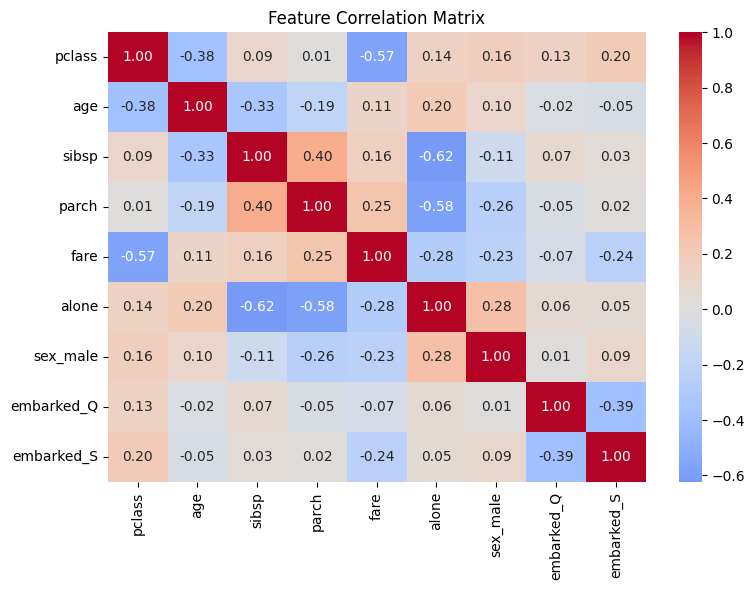

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(X_train.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

<Axes: >

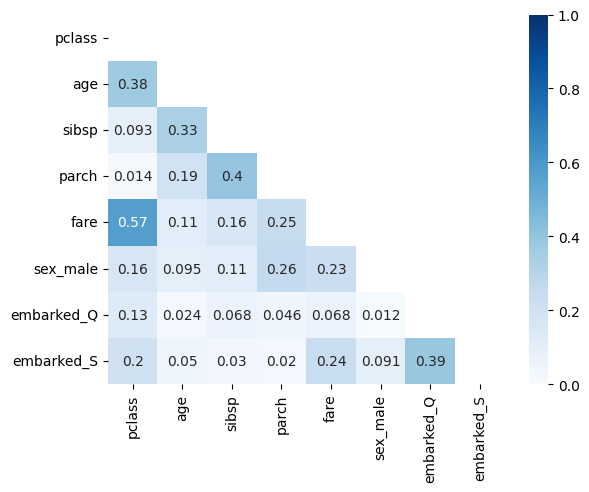

In [24]:
# The information in the bottom-left corner is identical to the information on the top-right corner.
# We can use a mask to render only the relevant info:

import numpy as np

mask = np.triu(np.ones_like(X_train.corr(), dtype=bool)) 

sns.heatmap(
    X_train.corr().abs(),
    annot=True,
    cmap="Blues",
    vmin=0, vmax=1,
    mask=mask
)

When training a machine learning model, strongly correlated features are often considered redundant because they carry similar information (can add noise without adding signal). 

In some cases —especially in linear models— this can increase noise or make the model less stable, so one of the correlated features may be removed or combined.

Important:
- This is not a strict rule: many algorithms (e.g. decision trees, neural networks), can handle correlated features well, and sometimes both features still contribute useful signal.
- Correlation between input features can indicate redundancy and may be reduced, but correlation with the target variable is usually useful and should not be removed.

Key idea:
- Feature ↔ Feature correlation: bad ❌
    - When two input features carry similar information, one may be reduced or combined to avoid redundancy and improve model stability.
- Feature ↔ Target correlation: good ✅
    - When a feature is strongly related to the label you're trying to predict, it is usually very valuable and should be kept because it helps the model learn.


<br>

In this example, `alone` is notably correlated with both `sibsp` (r ≈ -0.6) and `parch` (r ≈ -0.4). This makes sense — `alone` is `True` when `sibsp == 0` AND `parch == 0`. It's a derived feature that adds no new information.

We'll drop `alone` to reduce redundancy.

In [19]:
X_train = X_train.drop(columns=['alone'])
X_test = X_test.drop(columns=['alone'])

print("Final features:", X_train.columns.tolist())

Final features: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male', 'embarked_Q', 'embarked_S']


---

## 6. Model Training

### How Logistic Regression Works

Despite its name, Logistic Regression is a **classification** algorithm. Instead of predicting a continuous value, it predicts the **probability** that an input belongs to class 1 (survived).

It uses the **sigmoid function** to squash any value into the range [0, 1]:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

A threshold of **0.5** is then applied:
- Probability ≥ 0.5 → predict **survived (1)**
- Probability < 0.5 → predict **did not survive (0)**

<br>

![](../_images/logistic-regression-i.png)

<br>

![](../_images/logistic-regression-ii.png)

(Image source: [Medium](https://medium.com/@jramiroz98/logistic-regression-e5d784ba7b99))

<br>

Logistic regression first computes a weighted sum of the input features (like linear regression), then applies a sigmoid function to that result to convert it into a probability between 0 and 1:

![](../_images/logistic-regression-iii.jpg)

(Image source: [datahacker](https://datahacker.rs/004-machine-learning-logistic-regression-model/))

<br>
<br>



In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Model trained ✅")

Model trained ✅


Same 2-line pattern as Demo I: create the model → call `.fit()`. The `max_iter` parameter gives the solver enough iterations to converge on this dataset.

---

## 7. Model Evaluation

For **regression** we used R². For **classification**, two common tools are:
- **Accuracy** — fraction of predictions that were correct
- **Confusion Matrix** — a breakdown of correct and incorrect predictions by class

In [21]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)

### Accuracy

$$\text{Accuracy} = \frac{\text{Correct predictions}}{\text{Total predictions}}$$

Simple and intuitive, but it can be misleading with imbalanced classes — a model that always predicts "did not survive" would get 62% accuracy without learning anything useful.

In [22]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.2%}")

Accuracy: 79.72%


### Confusion Matrix

A confusion matrix shows **where** the model makes mistakes:

|  | Predicted: 0 | Predicted: 1 |
|--|-------------|-------------|
| **Actual: 0** | True Negative (TN) ✅ | False Positive (FP) ❌ |
| **Actual: 1** | False Negative (FN) ❌ | True Positive (TP) ✅ |

- **TN** — correctly predicted "did not survive"
- **TP** — correctly predicted "survived"
- **FP** — predicted "survived" but they didn't ❌
- **FN** — predicted "did not survive" but they did ❌

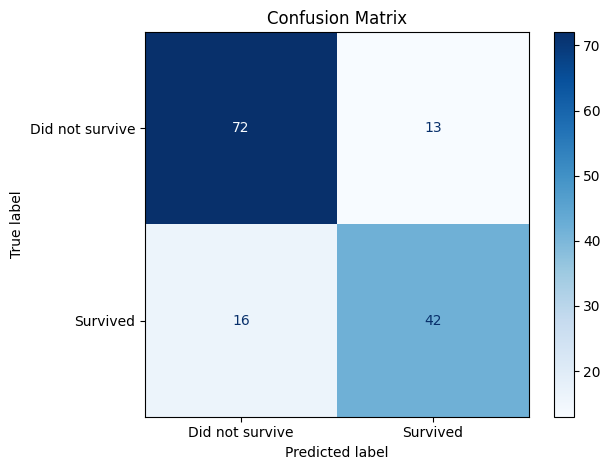

In [23]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred),
    display_labels=['Did not survive', 'Survived']
)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

**Interpretation:**
- The model is reasonably good at identifying passengers who **did not survive** (large TN count).
- It misses more survivors than non-survivors — partly because survivors are the minority class, and partly because we dropped `age`, which is a meaningful predictor of survival.

This is a known trade-off when doing simple data cleaning. Metrics like **precision**, **recall**, and **F1-score** give a fuller picture for imbalanced problems — but that's a topic for another session! 🚀